# 📡 Model Monitoring
Tracks performance over time and detects drift

Run anytime after `02_training_testing.ipynb`

---
### Cells
1. Imports & Config
2. Load Model & Test Data
3. Inference & Metrics
4. Confidence Analysis
5. Error Analysis
6. Drift Detection
7. Alerts
8. Log & Dashboard

## Cell 1 — Imports & Config

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from datetime import datetime
from pathlib import Path
from collections import Counter
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH  = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
ORIG_PATH     = r'D:\Files\AI X-Ray Detection\Dataset'
MODELS_PATH   = r'D:\Files\AI X-Ray Detection\Models'
RESULTS_PATH  = r'D:\Files\AI X-Ray Detection\Reports'
MONITOR_LOG   = r'D:\Files\AI X-Ray Detection\Reports\monitoring_log.csv'
CLASSES       = ['normal', 'pneumonia', 'tuberculosis']
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 16

ACCURACY_THRESHOLD   = 0.80
RECALL_THRESHOLD     = 0.75
DRIFT_THRESHOLD      = 0.05
CONFIDENCE_THRESHOLD = 0.60

if not os.path.exists(DATASET_PATH):
    DATASET_PATH = ORIG_PATH

now_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print(f'✅ Config ready')
print(f'   Timestamp: {now_str}')

✅ Config ready
   Timestamp: 2026-05-16 18:08:03


## Cell 2 — Load Model & Test Data

In [2]:
# Load best model info
best_info_path = os.path.join(RESULTS_PATH, 'best_model_info.json')
if os.path.exists(best_info_path):
    with open(best_info_path) as f:
        best_info = json.load(f)
    model_path  = best_info['model_path']
    CLASS_NAMES = best_info.get('class_names', CLASSES)
else:
    # Auto-discover latest model
    model_files = sorted(
        [os.path.join(MODELS_PATH,f) for f in os.listdir(MODELS_PATH)
         if f.endswith('.keras') or f.endswith('.h5')],
        key=os.path.getmtime, reverse=True)
    if not model_files:
        raise FileNotFoundError('No models found. Run 02_training_testing.ipynb first.')
    model_path  = model_files[0]
    CLASS_NAMES = CLASSES
    best_info   = {'best_model': Path(model_path).stem}

print(f'Loading: {best_info["best_model"]}')
model = tf.keras.models.load_model(model_path, compile=False)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    os.path.join(DATASET_PATH,'test'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

CLASS_NAMES = list(test_gen.class_indices.keys())
n_classes   = len(CLASS_NAMES)
print(f'Test samples : {test_gen.samples}')
print(f'Classes      : {CLASS_NAMES}')
print('✅ Model and data loaded')

Loading: EfficientNetB4_finetuned
Found 1451 images belonging to 3 classes.
Test samples : 1451
Classes      : ['normal', 'pneumonia', 'tuberculosis']
✅ Model and data loaded


## Cell 3 — Inference & Metrics

In [3]:
test_gen.reset()
start          = time.time()
y_pred         = model.predict(test_gen, verbose=1)
inference_time = time.time() - start
y_pred_classes = np.argmax(y_pred, axis=1)
y_true         = test_gen.classes
overall_acc    = float(accuracy_score(y_true, y_pred_classes))
per_img_ms     = inference_time / len(y_true) * 1000
y_true_bin     = label_binarize(y_true, classes=list(range(n_classes)))

report_dict = classification_report(y_true, y_pred_classes,
                target_names=CLASS_NAMES, output_dict=True)

print(f'\n  Accuracy       : {overall_acc*100:.2f}%')
print(f'  Inference time : {inference_time:.1f}s total | {per_img_ms:.1f} ms/image')

metrics = {}
print(f'\n  {"Class":<18} {"Precision":>10} {"Recall":>10} {"F1":>8} {"AUC":>8} Status')
print(f'  {"-"*62}')
for cls in CLASS_NAMES:
    cls_idx = CLASS_NAMES.index(cls)
    prec = report_dict.get(cls,{}).get('precision',0)
    rec  = report_dict.get(cls,{}).get('recall',0)
    f1   = report_dict.get(cls,{}).get('f1-score',0)
    try: auc = float(roc_auc_score(y_true_bin[:,cls_idx], y_pred[:,cls_idx]))
    except: auc = 0.0
    metrics[cls] = {'precision':prec,'recall':rec,'f1':f1,'auc':auc}
    flag = '✅' if rec>=RECALL_THRESHOLD else '❌ LOW'
    print(f'  {cls:<18} {prec:>10.4f} {rec:>10.4f} {f1:>8.4f} {auc:>8.4f}  {flag}')

91/91 ━━━━━━━━━━━━━━━━━━━━ 52s 538ms/step

  Accuracy       : 87.46%
  Inference time : 52.4s total | 36.1 ms/image

  Class               Precision     Recall       F1      AUC Status
  --------------------------------------------------------------
  normal                 0.8185     0.8529   0.8354   0.9530  ✅
  pneumonia              0.9111     0.9722   0.9406   0.9921  ✅
  tuberculosis           0.8968     0.8158   0.8544   0.9650  ✅


## Cell 4 — Confidence Analysis

In [4]:
max_conf      = np.max(y_pred, axis=1)
low_conf_mask = max_conf < CONFIDENCE_THRESHOLD
low_conf_pct  = float(np.sum(low_conf_mask)/len(max_conf)*100)

print(f'  Mean confidence     : {np.mean(max_conf):.4f}')
print(f'  Median confidence   : {np.median(max_conf):.4f}')
print(f'  Std confidence      : {np.std(max_conf):.4f}')
flag = '⚠️  HIGH' if low_conf_pct > 10 else '✅ OK'
print(f'  Low conf (<{CONFIDENCE_THRESHOLD}) pct : {low_conf_pct:.1f}%  {flag}')

print(f'\n  Per-class confidence:')
for cls in CLASS_NAMES:
    idx  = CLASS_NAMES.index(cls)
    mask = y_true == idx
    if mask.sum() > 0:
        conf = y_pred[mask, idx]
        print(f'    {cls:<18} mean={np.mean(conf):.4f}  min={np.min(conf):.4f}  max={np.max(conf):.4f}')

  Mean confidence     : 0.8097
  Median confidence   : 0.8591
  Std confidence      : 0.1406
  Low conf (<0.6) pct : 12.6%  ⚠️  HIGH

  Per-class confidence:
    normal             mean=0.7440  min=0.0685  max=0.9523
    pneumonia          mean=0.8199  min=0.0636  max=0.9880
    tuberculosis       mean=0.7514  min=0.0017  max=0.9983


## Cell 5 — Error Analysis

In [5]:
misclassified = np.where(y_pred_classes != y_true)[0]
print(f'  Misclassified : {len(misclassified)}/{len(y_true)} ({len(misclassified)/len(y_true)*100:.1f}%)')

cm = confusion_matrix(y_true, y_pred_classes)
error_pairs = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i,j] > 0:
            error_pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], cm[i,j]))
error_pairs.sort(key=lambda x: x[2], reverse=True)

print(f'\n  Most confused pairs:')
for tc, pc, count in error_pairs[:5]:
    print(f'    True={tc:<18} → Pred={pc:<18} : {count} times')

hcw = np.where((y_pred_classes != y_true) & (max_conf > 0.85))[0]
print(f'\n  High-confidence wrong (>85%): {len(hcw)}')
if len(hcw) > 0:
    print('  ⚠️  Model is confidently wrong on these cases:')
    for idx in hcw[:5]:
        print(f'    True={CLASS_NAMES[y_true[idx]]:<18} Pred={CLASS_NAMES[y_pred_classes[idx]]:<18} Conf={max_conf[idx]:.3f}')

  Misclassified : 182/1451 (12.5%)

  Most confused pairs:
    True=tuberculosis       → Pred=normal             : 83 times
    True=normal             → Pred=tuberculosis       : 46 times
    True=normal             → Pred=pneumonia          : 24 times
    True=tuberculosis       → Pred=pneumonia          : 17 times
    True=pneumonia          → Pred=normal             : 7 times

  High-confidence wrong (>85%): 14
  ⚠️  Model is confidently wrong on these cases:
    True=normal             Pred=tuberculosis       Conf=0.853
    True=normal             Pred=pneumonia          Conf=0.902
    True=normal             Pred=tuberculosis       Conf=0.863
    True=tuberculosis       Pred=pneumonia          Conf=0.942
    True=tuberculosis       Pred=normal             Conf=0.880


## Cell 6 — Drift Detection

In [6]:
drift_detected = False
prev_acc       = None

if os.path.exists(MONITOR_LOG):
    df_log = pd.read_csv(MONITOR_LOG)
    if len(df_log) > 0:
        prev_acc       = float(df_log.iloc[-1]['accuracy'])
        acc_drop       = prev_acc - overall_acc
        drift_detected = acc_drop > DRIFT_THRESHOLD

        print(f'  Previous accuracy : {prev_acc*100:.2f}%')
        print(f'  Current accuracy  : {overall_acc*100:.2f}%')
        print(f'  Change            : {(overall_acc-prev_acc)*100:+.2f}%')

        if drift_detected:
            print(f'  ❌ DRIFT DETECTED — dropped {acc_drop*100:.2f}% (threshold: {DRIFT_THRESHOLD*100}%)')
            print(f'     Action: Consider retraining with new data')
        elif overall_acc < prev_acc:
            print(f'  ⚠️  Minor decline — monitor closely')
        else:
            print(f'  ✅ No drift — model stable')

        if len(df_log) >= 2:
            print(f'\n  Recent runs:')
            print(f'  {"Timestamp":<22} {"Accuracy":>10} {"Alert"}')
            for _, row in df_log.tail(5).iterrows():
                acc   = float(row['accuracy'])
                alert = '❌' if acc < ACCURACY_THRESHOLD else '✅'
                print(f'  {str(row["timestamp"]):<22} {acc:>10.4f} {alert}')
else:
    print('  ℹ️  First monitoring run — no history yet')

  ℹ️  First monitoring run — no history yet


## Cell 7 — Alerts

In [7]:
alerts = []
if overall_acc < ACCURACY_THRESHOLD:
    alerts.append(f'❌ CRITICAL: Accuracy {overall_acc*100:.1f}% below threshold {ACCURACY_THRESHOLD*100}%')
for cls in CLASS_NAMES:
    rec = metrics[cls]['recall']
    if rec < RECALL_THRESHOLD:
        alerts.append(f'❌ LOW RECALL: {cls} = {rec:.3f} (threshold: {RECALL_THRESHOLD})')
if low_conf_pct > 15:
    alerts.append(f'⚠️  HIGH uncertainty: {low_conf_pct:.1f}% predictions below {CONFIDENCE_THRESHOLD}')
if drift_detected:
    alerts.append(f'🔴 DRIFT: Accuracy dropped significantly since last run')
if len(hcw) > len(y_true) * 0.02:
    alerts.append(f'⚠️  {len(hcw)} high-confidence wrong predictions')

print('SYSTEM ALERTS')
print('='*50)
if alerts:
    for alert in alerts:
        print(f'  {alert}')
else:
    print('  ✅ All checks passed — model performing well')

SYSTEM ALERTS
  ✅ All checks passed — model performing well


## Cell 8 — Log & Dashboard

  Log updated (1 entries) → D:\Files\AI X-Ray Detection\Reports\monitoring_log.csv


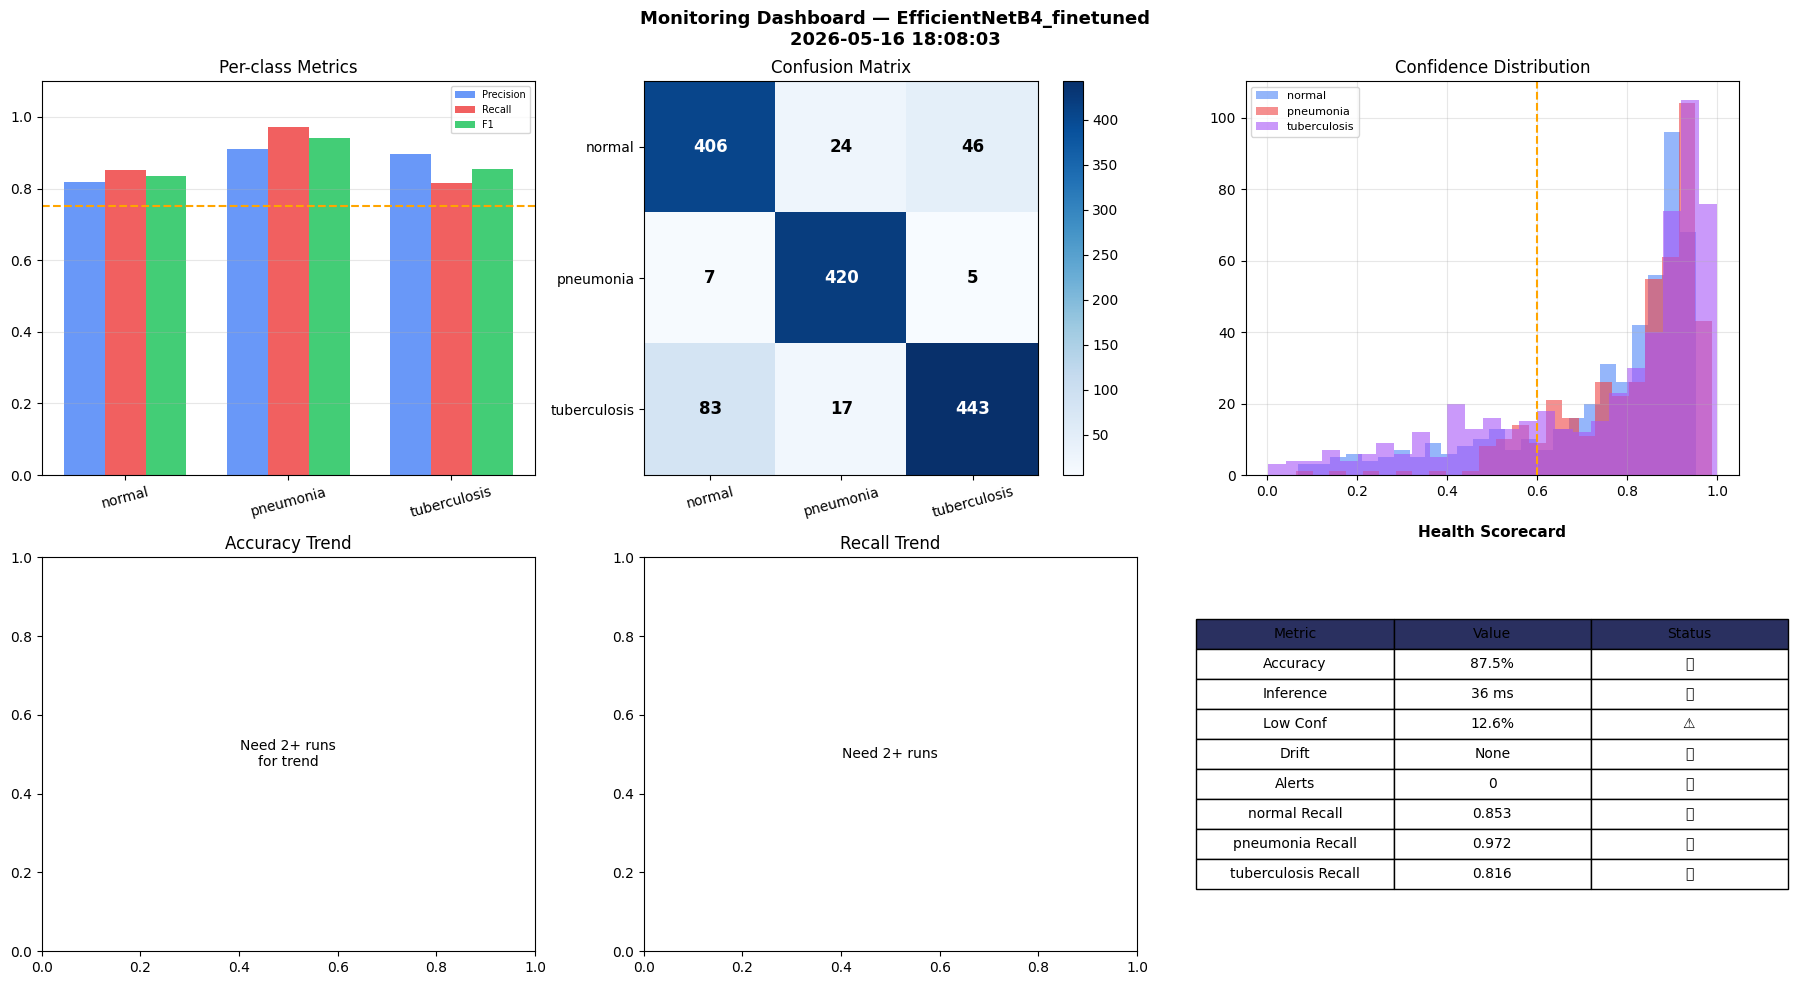


  Dashboard saved → D:\Files\AI X-Ray Detection\Reports\monitoring_dashboard.png
  Accuracy  : 87.46%
  Drift     : ✅ None
  Alerts    : 0 active

✅ Monitoring complete


In [8]:
# Log this run
log_row = {
    'timestamp'    : now_str,
    'model_name'   : best_info['best_model'],
    'accuracy'     : round(overall_acc, 4),
    'inference_ms' : round(per_img_ms, 2),
    'low_conf_pct' : round(low_conf_pct, 2),
    'n_alerts'     : len(alerts),
    'drift_detected': drift_detected,
}
for cls in CLASS_NAMES:
    log_row[f'{cls}_recall'] = round(metrics[cls]['recall'], 4)
    log_row[f'{cls}_auc']    = round(metrics[cls]['auc'], 4)

if os.path.exists(MONITOR_LOG):
    df_log = pd.read_csv(MONITOR_LOG)
    df_log = pd.concat([df_log, pd.DataFrame([log_row])], ignore_index=True)
else:
    df_log = pd.DataFrame([log_row])
df_log.to_csv(MONITOR_LOG, index=False)
print(f'  Log updated ({len(df_log)} entries) → {MONITOR_LOG}')

# Dashboard
colors = ['#4f86f7','#ef4444','#a855f7']
fig = plt.figure(figsize=(18, 10))
fig.suptitle(f'Monitoring Dashboard — {best_info["best_model"]}\n{now_str}',
             fontsize=13, fontweight='bold')

# Per-class metrics
ax1 = fig.add_subplot(2, 3, 1)
x, w = np.arange(len(CLASS_NAMES)), 0.25
ax1.bar(x-w, [metrics[c]['precision'] for c in CLASS_NAMES], w, label='Precision', color='#4f86f7', alpha=0.85)
ax1.bar(x,   [metrics[c]['recall']    for c in CLASS_NAMES], w, label='Recall',    color='#ef4444', alpha=0.85)
ax1.bar(x+w, [metrics[c]['f1']        for c in CLASS_NAMES], w, label='F1',        color='#22c55e', alpha=0.85)
ax1.axhline(y=RECALL_THRESHOLD, color='orange', linestyle='--')
ax1.set_xticks(x); ax1.set_xticklabels(CLASS_NAMES, rotation=15)
ax1.set_title('Per-class Metrics'); ax1.legend(fontsize=7)
ax1.set_ylim(0,1.1); ax1.grid(axis='y',alpha=0.3)

# Confusion Matrix
ax2 = fig.add_subplot(2, 3, 2)
im  = ax2.imshow(cm, cmap=plt.cm.Blues)
thresh = cm.max()/2.
for i in range(n_classes):
    for j in range(n_classes):
        ax2.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=12,fontweight='bold',
                 color='white' if cm[i,j]>thresh else 'black')
ax2.set_xticks(range(n_classes)); ax2.set_yticks(range(n_classes))
ax2.set_xticklabels(CLASS_NAMES,rotation=15); ax2.set_yticklabels(CLASS_NAMES)
ax2.set_title('Confusion Matrix'); plt.colorbar(im,ax=ax2)

# Confidence distribution
ax3 = fig.add_subplot(2, 3, 3)
for cls, color in zip(CLASS_NAMES, colors):
    idx  = CLASS_NAMES.index(cls)
    mask = y_true == idx
    if mask.sum() > 0:
        ax3.hist(y_pred[mask,idx], bins=25, alpha=0.6, color=color, label=cls)
ax3.axvline(x=CONFIDENCE_THRESHOLD, color='orange', linestyle='--')
ax3.set_title('Confidence Distribution'); ax3.legend(fontsize=8); ax3.grid(True,alpha=0.3)

# Accuracy trend
ax4 = fig.add_subplot(2, 3, 4)
if len(df_log) > 1:
    ax4.plot(range(len(df_log)), df_log['accuracy'], 'o-', color='#4f86f7', linewidth=2)
    ax4.axhline(y=ACCURACY_THRESHOLD, color='orange', linestyle='--', label='Threshold')
    ax4.set_title('Accuracy Over Time'); ax4.set_xlabel('Run #'); ax4.set_ylabel('Accuracy')
    ax4.legend(); ax4.grid(True,alpha=0.3); ax4.set_ylim(0,1.05)
else:
    ax4.text(0.5,0.5,'Need 2+ runs\nfor trend',ha='center',va='center',transform=ax4.transAxes)
    ax4.set_title('Accuracy Trend')

# Recall trend
ax5 = fig.add_subplot(2, 3, 5)
if len(df_log) > 1:
    for cls, color in zip(CLASS_NAMES, colors):
        col = f'{cls}_recall'
        if col in df_log.columns:
            ax5.plot(range(len(df_log)), df_log[col], 'o-', color=color, linewidth=2, label=cls)
    ax5.axhline(y=RECALL_THRESHOLD, color='orange', linestyle='--')
    ax5.set_title('Recall Trend'); ax5.legend(fontsize=8); ax5.grid(True,alpha=0.3)
else:
    ax5.text(0.5,0.5,'Need 2+ runs',ha='center',va='center',transform=ax5.transAxes)
    ax5.set_title('Recall Trend')

# Scorecard
ax6 = fig.add_subplot(2, 3, 6); ax6.axis('off')
scorecard = [['Metric','Value','Status'],
             ['Accuracy', f'{overall_acc*100:.1f}%', '✅' if overall_acc>=ACCURACY_THRESHOLD else '❌'],
             ['Inference', f'{per_img_ms:.0f} ms', '✅'],
             ['Low Conf', f'{low_conf_pct:.1f}%', '✅' if low_conf_pct<10 else '⚠️'],
             ['Drift', 'None' if not drift_detected else 'YES', '✅' if not drift_detected else '❌'],
             ['Alerts', str(len(alerts)), '✅' if not alerts else '❌']]
for cls in CLASS_NAMES:
    rec = metrics[cls]['recall']
    scorecard.append([f'{cls} Recall', f'{rec:.3f}', '✅' if rec>=RECALL_THRESHOLD else '❌'])

tbl = ax6.table(cellText=scorecard[1:], colLabels=scorecard[0],
                cellLoc='center', loc='center',
                colColours=['#2a3060','#2a3060','#2a3060'])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.6)
ax6.set_title('Health Scorecard', fontsize=11, fontweight='bold', pad=15)

plt.tight_layout()
dashboard_path = os.path.join(RESULTS_PATH, 'monitoring_dashboard.png')
plt.savefig(dashboard_path, dpi=130, bbox_inches='tight')
plt.show()

print(f'\n  Dashboard saved → {dashboard_path}')
print(f'  Accuracy  : {overall_acc*100:.2f}%')
print(f'  Drift     : {"❌ DETECTED" if drift_detected else "✅ None"}')
print(f'  Alerts    : {len(alerts)} active')
print(f'\n✅ Monitoring complete')